# Predicting Ordering Intent Through Enhanced User Interaction Signals

This project focuses on predicting whether an online shopper is likely to make a purchase based on their browsing behavior and user interaction signals. Machine learning models such as Logistic Regression, Random Forest, and Gradient Boosting were trained and evaluated using behavioral and session-related features. The goal is to identify purchase intent and understand which user interactions are most associated with ordering behavior.

In [38]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_curve

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [39]:
df = pd.read_csv('data\\online_shoppers_intention.csv')
print('Shape', df.shape)
df.head(5)

Shape (12330, 18)


,AcctPagesViewed,AcctPageTime,InfoPagesViewed,InfoPageTime,ProductPagesViewed,ProductPageTime,AvgBounceRate,AvgExitRate,AvgPageValue,ProximityToSpecialDay,VisitMonth,UserOS,UserBrowser,UserRegion,SourceChannel,UserCategory,IsWeekendVisit,MadePurchase
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AcctPagesViewed,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
AcctPageTime,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
InfoPagesViewed,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
InfoPageTime,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductPagesViewed,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductPageTime,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
AvgBounceRate,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
AvgExitRate,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
AvgPageValue,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
ProximityToSpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [41]:
df.isnull().sum()

AcctPagesViewed          0
AcctPageTime             0
InfoPagesViewed          0
InfoPageTime             0
ProductPagesViewed       0
ProductPageTime          0
AvgBounceRate            0
AvgExitRate              0
AvgPageValue             0
ProximityToSpecialDay    0
VisitMonth               0
UserOS                   0
UserBrowser              0
UserRegion               0
SourceChannel            0
UserCategory             0
IsWeekendVisit           0
MadePurchase             0
dtype: int64

`Observation`
* Containing no missing values...

In [42]:
print("\nTarget distribution:")
print(df["MadePurchase"].value_counts())


Target distribution:
MadePurchase
False    10422
True      1908
Name: count, dtype: int64


In [43]:
print("\nTarget percentage:")
print(df["MadePurchase"].value_counts(normalize=True) * 100)


Target percentage:
MadePurchase
False    84.525547
True     15.474453
Name: proportion, dtype: float64


In [44]:
df = df.drop_duplicates().reset_index(drop=True)
print("shape after removing duplicates:", df.shape)

shape after removing duplicates: (12205, 18)


In [45]:
X = df.drop("MadePurchase", axis=1)
y = df["MadePurchase"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12205, 17)
y shape: (12205,)


In [46]:
print(
    'Correlation of AvgPageValue with MadePurchase:',
    df['AvgPageValue'].corr(df['MadePurchase'])
)

Correlation of AvgPageValue with MadePurchase: 0.49189397887644454


In [47]:
drop_avgVal = False

if drop_avgVal:
    X = X.drop('AvgPageValue', axis = 1)

Identify categorical columns

In [48]:
categorical_features = [
    "VisitMonth",
    "UserOS",
    "UserBrowser",
    "UserRegion",
    "SourceChannel",
    "UserCategory",
    "IsWeekendVisit"
]

categorical_features = [
    col for col in categorical_features
    if col in X.columns
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numeric_features)

Categorical:
['VisitMonth', 'UserOS', 'UserBrowser', 'UserRegion', 'SourceChannel', 'UserCategory', 'IsWeekendVisit']

Numerical:
['AcctPagesViewed', 'AcctPageTime', 'InfoPagesViewed', 'InfoPageTime', 'ProductPagesViewed', 'ProductPageTime', 'AvgBounceRate', 'AvgExitRate', 'AvgPageValue', 'ProximityToSpecialDay']


# Train/Validation/test split 
* 60% training, 20% validation, and 20% test

In [49]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True))

print("\nValidation target:")
print(y_val.value_counts(normalize=True))

print("\nTesting target:")
print(y_test.value_counts(normalize=True))

Training: (7323, 17)
Validation: (2441, 17)
Testing: (2441, 17)

Training target:
MadePurchase
0    0.843643
1    0.156357
Name: proportion, dtype: float64

Validation target:
MadePurchase
0    0.843916
1    0.156084
Name: proportion, dtype: float64

Testing target:
MadePurchase
0    0.843507
1    0.156493
Name: proportion, dtype: float64


Preprocessing for Logistic Regression

In [50]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [51]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Logistic Regression

In [52]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['AcctPagesViewed','AcctPageTime','InfoPagesViewed',...,'SourceChannel', 'UserCategory','IsWeekendVisit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

# Tree Models : Random Forest and Gradient Boosting

In [53]:
tree_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

tree_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

tree_preprocessor = ColumnTransformer([
    ("num", tree_numeric_pipeline, numeric_features),
    ("cat", tree_categorical_pipeline, categorical_features)
])

# Random Forest

In [54]:
rf_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['AcctPagesViewed','AcctPageTime','InfoPagesViewed',...,'SourceChannel', 'UserCategory','IsWeekendVisit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

# Gradient Boosting

In [55]:
gb_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [56]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [ ]:
gb_model.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

# Validation Based Thershold Selection

In [ ]:
def find_best_threshold(y_true, probabilities):
    thresholds = np.arange(0.10, 0.91, 0.01)
    threshold_results = []

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)

        threshold_results.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, predictions, zero_division=0),
            "Recall": recall_score(y_true, predictions, zero_division=0),
            "F1": f1_score(y_true, predictions, zero_division=0)
        })

    threshold_df = pd.DataFrame(threshold_results)
    best_row = threshold_df.loc[threshold_df["F1"].idxmax()]

    return float(best_row["Threshold"]), threshold_df

In [ ]:
lr_val_prob = logistic_model.predict_proba(X_val)[:, 1]
rf_val_prob = rf_model.predict_proba(X_val)[:, 1]
gb_val_prob = gb_model.predict_proba(X_val)[:, 1]

lr_threshold, lr_threshold_df = find_best_threshold(y_val, lr_val_prob)
rf_threshold, rf_threshold_df = find_best_threshold(y_val, rf_val_prob)
gb_threshold, gb_threshold_df = find_best_threshold(y_val, gb_val_prob)

print("Logistic Regression threshold:", lr_threshold)
print("Random Forest threshold     :", rf_threshold)
print("Gradient Boosting threshold :", gb_threshold)

Logistic Regression threshold: 0.6299999999999997
Random Forest threshold     : 0.4299999999999998
Gradient Boosting threshold : 0.6799999999999997


In [ ]:
validation_threshold_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Threshold": [lr_threshold, rf_threshold, gb_threshold],
    "Validation Precision": [
        precision_score(y_val, (lr_val_prob >= lr_threshold).astype(int), zero_division=0),
        precision_score(y_val, (rf_val_prob >= rf_threshold).astype(int), zero_division=0),
        precision_score(y_val, (gb_val_prob >= gb_threshold).astype(int), zero_division=0)
    ],
    "Validation Recall": [
        recall_score(y_val, (lr_val_prob >= lr_threshold).astype(int), zero_division=0),
        recall_score(y_val, (rf_val_prob >= rf_threshold).astype(int), zero_division=0),
        recall_score(y_val, (gb_val_prob >= gb_threshold).astype(int), zero_division=0)
    ],
    "Validation F1": [
        f1_score(y_val, (lr_val_prob >= lr_threshold).astype(int), zero_division=0),
        f1_score(y_val, (rf_val_prob >= rf_threshold).astype(int), zero_division=0),
        f1_score(y_val, (gb_val_prob >= gb_threshold).astype(int), zero_division=0)
    ]
})

validation_threshold_results.round(4)

,Model,Threshold,Validation Precision,Validation Recall,Validation F1
0,Logistic Regression,0.63,0.6160,0.6273,0.6216
1,Random Forest,0.43,0.5689,0.7480,0.6463
2,Gradient Boosting,0.68,0.6040,0.7165,0.6555


# Final Test Predictions

In [ ]:
lr_test_prob = logistic_model.predict_proba(X_test)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]
gb_test_prob = gb_model.predict_proba(X_test)[:, 1]

lr_test_pred = (lr_test_prob >= lr_threshold).astype(int)
rf_test_pred = (rf_test_prob >= rf_threshold).astype(int)
gb_test_pred = (gb_test_prob >= gb_threshold).astype(int)

Final Model Evaluation on the Unseen Test Set

In [ ]:
def evaluate_model(name, y_true, predictions, probabilities):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities)
    }

final_results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, lr_test_pred, lr_test_prob),
    evaluate_model("Random Forest", y_test, rf_test_pred, rf_test_prob),
    evaluate_model("Gradient Boosting", y_test, gb_test_pred, gb_test_prob)
])

final_results["Threshold"] = [lr_threshold, rf_threshold, gb_threshold]
final_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Threshold
0,Logistic Regression,0.8878,0.6317,0.6780,0.6540,0.9110,0.6659,0.63
1,Random Forest,0.8837,0.6000,0.7696,0.6743,0.9248,0.7252,0.43
2,Gradient Boosting,0.8910,0.6261,0.7539,0.6841,0.9321,0.7248,0.68


In [ ]:
print("LOGISTIC REGRESSION")
print(classification_report(
    y_test,
    lr_test_pred,
    target_names=["No Purchase", "Purchase"]
))

print("\nRANDOM FOREST")
print(classification_report(
    y_test,
    rf_test_pred,
    target_names=["No Purchase", "Purchase"]
))

print("\nGRADIENT BOOSTING")
print(classification_report(
    y_test,
    gb_test_pred,
    target_names=["No Purchase", "Purchase"]
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

 No Purchase       0.94      0.93      0.93      2059
    Purchase       0.63      0.68      0.65       382

    accuracy                           0.89      2441
   macro avg       0.79      0.80      0.79      2441
weighted avg       0.89      0.89      0.89      2441


RANDOM FOREST
              precision    recall  f1-score   support

 No Purchase       0.95      0.90      0.93      2059
    Purchase       0.60      0.77      0.67       382

    accuracy                           0.88      2441
   macro avg       0.78      0.84      0.80      2441
weighted avg       0.90      0.88      0.89      2441


GRADIENT BOOSTING
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.93      2059
    Purchase       0.63      0.75      0.68       382

    accuracy                           0.89      2441
   macro avg       0.79      0.84      0.81      2441
weighted avg       0

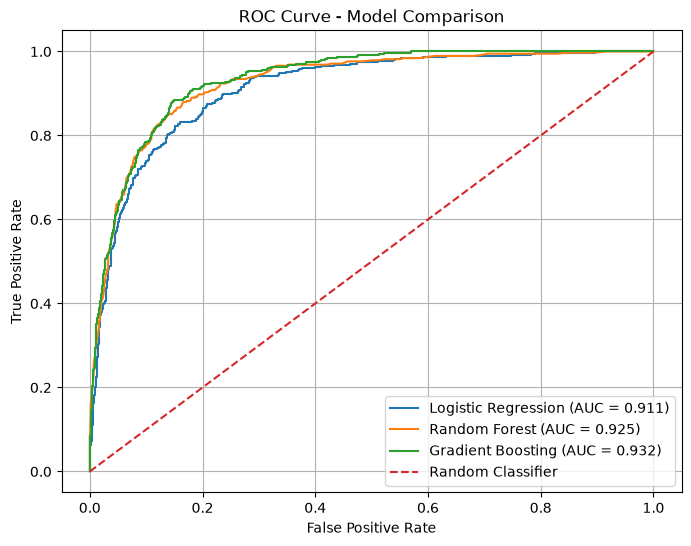

In [ ]:
plt.figure(figsize=(8, 6))

models = {
    "Logistic Regression": lr_test_prob,
    "Random Forest": rf_test_prob,
    "Gradient Boosting": gb_test_prob
}

for name, probabilities in models.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.grid()
plt.show()

Compare All Three Models

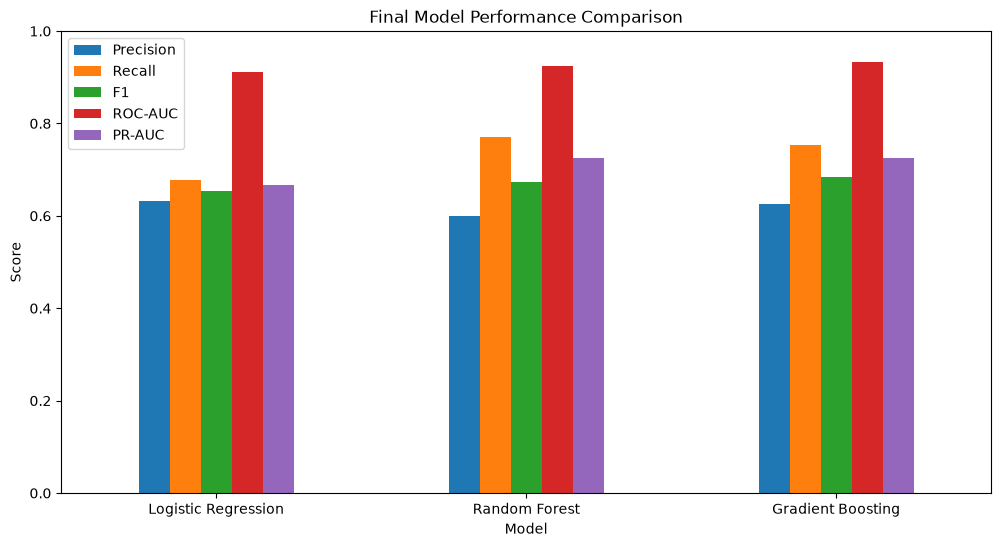

In [ ]:
final_results.set_index("Model")[
    ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

Confusion Matrices

[[1908  151]
 [ 123  259]]


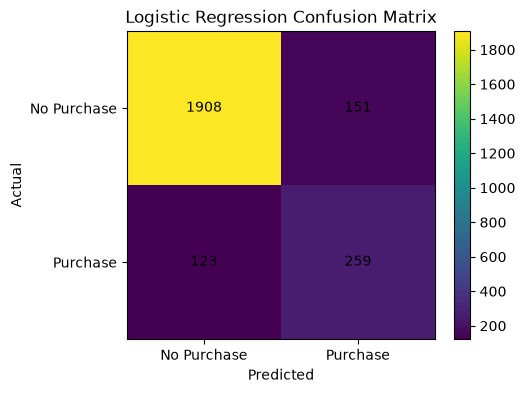

[[1863  196]
 [  88  294]]


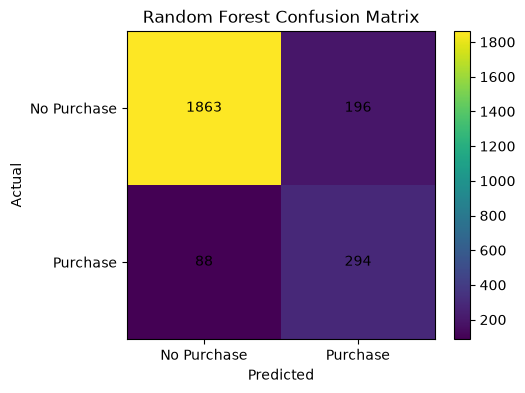

[[1887  172]
 [  94  288]]


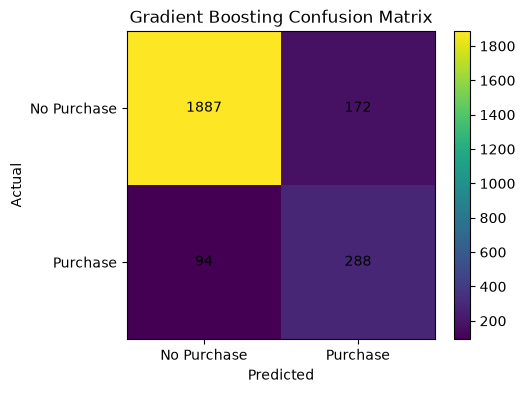

In [ ]:
def plot_confusion_matrix(y_true, predictions, title):
    cm = confusion_matrix(y_true, predictions, labels=[0, 1])

    print(cm)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.xticks([0, 1], ["No Purchase", "Purchase"])
    plt.yticks([0, 1], ["No Purchase", "Purchase"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

plot_confusion_matrix(y_test, lr_test_pred, "Logistic Regression Confusion Matrix")
plot_confusion_matrix(y_test, rf_test_pred, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, gb_test_pred, "Gradient Boosting Confusion Matrix")

In [ ]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
8,num__AvgPageValue,0.342895
7,num__AvgExitRate,0.091758
5,num__ProductPageTime,0.080298
4,num__ProductPagesViewed,0.068349
6,num__AvgBounceRate,0.050909
1,num__AcctPageTime,0.045982
0,num__AcctPagesViewed,0.039666
17,cat__VisitMonth_Nov,0.025660
3,num__InfoPageTime,0.020287
2,num__InfoPagesViewed,0.015083


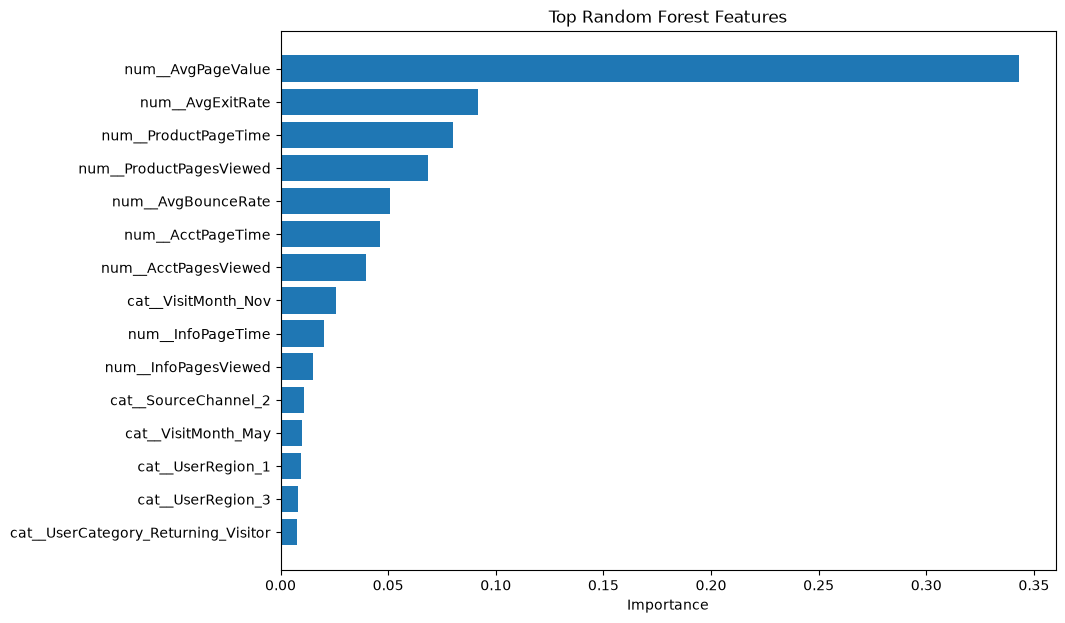

In [ ]:
top_features = importance_df.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top Random Forest Features")

plt.show()

In [ ]:
fairness_df = X_test.copy()

fairness_df["Actual"] = y_test.values
fairness_df["Predicted"] = rf_test_pred
fairness_df["Probability"] = rf_test_prob

In [ ]:
group_results = []

for group in fairness_df["UserCategory"].unique():

    group_data = fairness_df[
        fairness_df["UserCategory"] == group
    ]

    actual = group_data["Actual"]
    predicted = group_data["Predicted"]

    tn, fp, fn, tp = confusion_matrix(
        actual,
        predicted,
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    group_results.append({
        "UserCategory": group,
        "Samples": len(group_data),
        "Actual Purchases": actual.sum(),
        "Precision": precision_score(
            actual,
            predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            actual,
            predicted,
            zero_division=0
        ),
        "F1": f1_score(
            actual,
            predicted,
            zero_division=0
        ),
        "False Positive Rate": fpr,
        "False Negative Rate": fnr
    })

fairness_results = pd.DataFrame(group_results)

fairness_results

,UserCategory,Samples,Actual Purchases,Precision,Recall,F1,False Positive Rate,False Negative Rate
0,Returning_Visitor,2084,285,0.546135,0.768421,0.638484,0.101167,0.231579
1,New_Visitor,344,97,0.852273,0.773196,0.810811,0.052632,0.226804
2,Other,13,0,0.000000,0.000000,0.000000,0.076923,0.000000


In [ ]:
for feature in [
    "UserOS",
    "UserBrowser",
    "UserRegion",
    "SourceChannel"
]:
    
    print("\n==========================")
    print(feature)
    print("==========================")

    print(
        fairness_df.groupby(feature)["Actual"].agg(
            ["count", "sum", "mean"]
        )
    )


UserOS
        count  sum      mean
UserOS                      
1         539   84  0.155844
2        1304  232  0.177914
3         482   49  0.101660
4          95   15  0.157895
5           1    0  0.000000
6           7    0  0.000000
7           1    0  0.000000
8          12    2  0.166667

UserBrowser
             count  sum      mean
UserBrowser                      
1              508   80  0.157480
2             1566  238  0.151980
3               21    1  0.047619
4              170   31  0.182353
5               69   14  0.202899
6               29    4  0.137931
7               12    4  0.333333
8               24    3  0.125000
10              34    6  0.176471
11               1    0  0.000000
12               2    1  0.500000
13               5    0  0.000000

UserRegion
            count  sum      mean
UserRegion                      
1             924  156  0.168831
2             235   39  0.165957
3             448   65  0.145089
4             240   42  0.175000
5  

Correlation Analysis

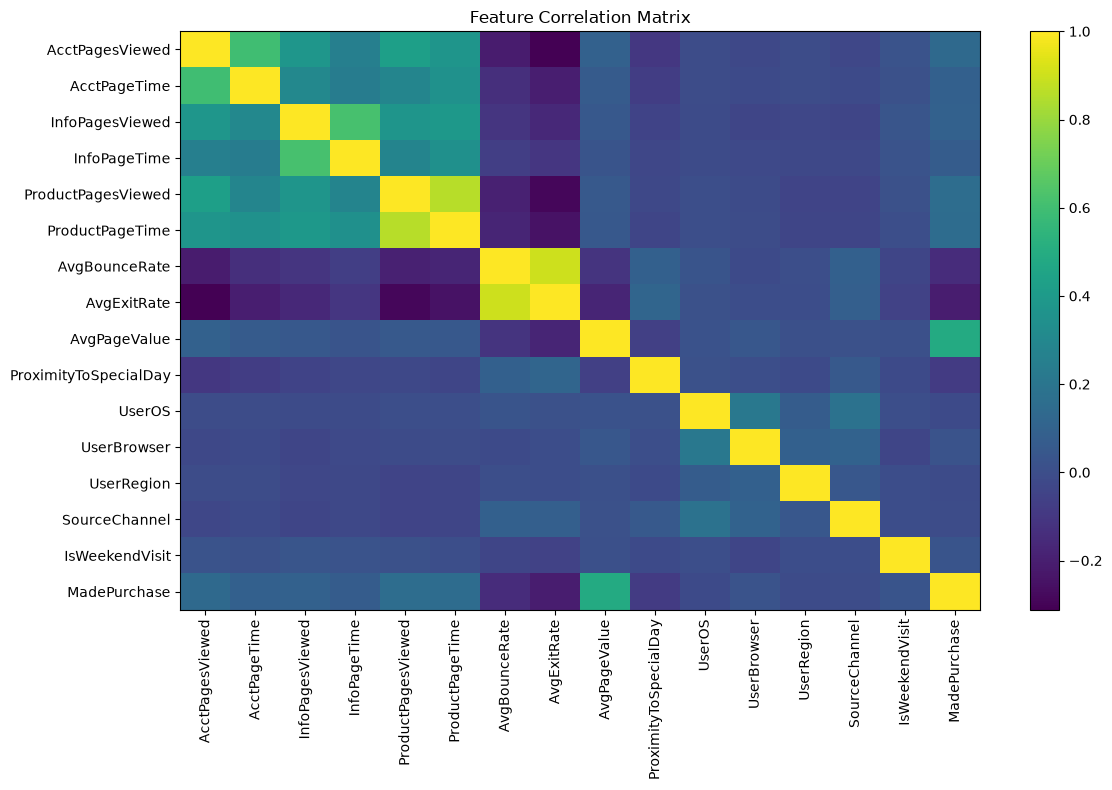

In [ ]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
print(
    "AvgBounceRate vs AvgExitRate:",
    df["AvgBounceRate"].corr(df["AvgExitRate"])
)

print(
    "ProductPagesViewed vs ProductPageTime:",
    df["ProductPagesViewed"].corr(
        df["ProductPageTime"]
    )
)

AvgBounceRate vs AvgExitRate: 0.9021443956243388
ProductPagesViewed vs ProductPageTime: 0.8603298646587776


In [ ]:
final_report = final_results.copy()

final_report[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Threshold"
    ]
].round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Threshold
0,Logistic Regression,0.8878,0.6317,0.6780,0.6540,0.9110,0.6659,0.63
1,Random Forest,0.8837,0.6000,0.7696,0.6743,0.9248,0.7252,0.43
2,Gradient Boosting,0.8910,0.6261,0.7539,0.6841,0.9321,0.7248,0.68
